<a href="https://colab.research.google.com/github/Farres26/CIS-3902-AI-MLFARRESAMRHAR/blob/main/Machine_Learning_for_Network_Intrusion_Detection_UNSW_NB15_AnalysisFINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Machine Learning for Network Intrusion Detection: UNSW-NB15 Analysis**

Created by: Farres Amrhar

**Introduction:**

In this project we will be using the UNSW-NB15 dataset to classify network traffic as either normal or malicious. The UNSW-NB15 dataset was created using the IXIA PerfectStorm tool in the Cyber Range Lab of the Australian Centre for Cyber Security (ACCS), generating a hybrid of real modern  normal activities and fake attack behaviors across nine attack categories. Using models including Random Forest, we aim to build a reliable detection system that can support cybersecurity decision making by accurately identifying malicious traffic in real-time.

**DELIVERABLE 1: Problem Definition and Data Acquisition**


**Problem statement:**

This project will try to predict cyber attacks using machine learning. Which can help prevent cyber attacks from being as devistating.

**Why did I pick this dataset?:**

The reason I chose this dataset is because I found this to be a very interesting topic because its data we can you to develop prevention before an attack even happens. And now and days cyberseciurty is becoming more and more important.

In [ ]:
#LOADS DATASET WITH API TOKEN RESPOND 'Y' to all
import os

#token for dataset use
os.environ['KAGGLE_TOKEN'] = 'KGAT_6116ddda1bfff3872bc75da9e9097a3f'

# Download and unzip
!kaggle datasets download -d mrwellsdavid/unsw-nb15
!unzip unsw-nb15.zip

# Confirm files are there
!ls

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
unsw-nb15.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  unsw-nb15.zip
replace NUSW-NB15_features.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: NUSW-NB15_features.csv  
replace UNSW-NB15_1.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW-NB15_1.csv         
replace UNSW-NB15_2.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW-NB15_2.csv         
replace UNSW-NB15_3.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW-NB15_3.csv         
replace UNSW-NB15_4.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW-NB15_4.csv         
replace UNSW-NB15_LIST_EVENTS.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW-NB15_LIST_EVENTS.csv  
replace UNSW_NB15_testing-set.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW_NB15_testing-set.csv  
replace UNSW_NB15_training-set.csv? [

In [ ]:

# Install kaggle, upload your kaggle.json API key, then:
!kaggle datasets download -d mrwellsdavid/unsw-nb15
!unzip unsw-nb15.zip

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
unsw-nb15.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  unsw-nb15.zip
replace NUSW-NB15_features.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: NUSW-NB15_features.csv  
replace UNSW-NB15_1.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW-NB15_1.csv         y

replace UNSW-NB15_2.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: UNSW-NB15_2.csv         y

replace UNSW-NB15_3.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: UNSW-NB15_3.csv         y

replace UNSW-NB15_4.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: UNSW-NB15_4.csv         
replace UNSW-NB15_LIST_EVENTS.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW-NB15_LIST_EVENTS.csv  
replace UNSW_NB15_testing-set.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW_NB15_testing-set.csv  
replace UNSW_NB15_training-set.csv? [

In [ ]:
import pandas as pd

train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df = pd.read_csv('UNSW_NB15_testing-set.csv')

print("Training set:", train_df.shape) #Data used for learning
print("Testing set:", test_df.shape) #Data used to test knowledge
train_df.head()

Training set: (82332, 45)
Testing set: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
#shows us all the column names and data types
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [ ]:
#shows us any uneven distribution in the data
print("Training distribution:")
print(train_df['label'].value_counts())
print(train_df['label'].value_counts(normalize=True) * 100)

Training distribution:
label
1    45332
0    37000
Name: count, dtype: int64
label
1    55.060001
0    44.939999
Name: proportion, dtype: float64


**What does this show us?:**

The cells above shows us that the training set contains 45,332 attacks (which is about 55%) and 37,000 normal records (47%). This shows us linear class distribution which is good.

In [ ]:
#Shows us the min,max,mean for data
train_df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,41166.500000,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,...,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,23767.345519,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,...,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20583.750000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,41166.500000,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,61749.250000,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,82332.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,...,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


The cell above is the summary of the data by showing us the mean,median,min,max,ect. This helps us get a better idea of the variance of the attacks which will be visualed in the data bellow

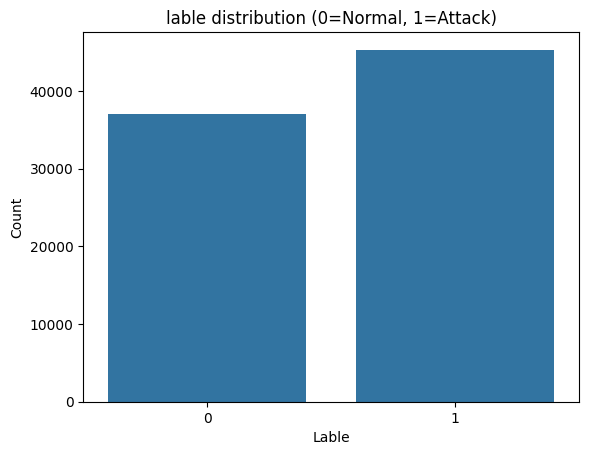

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#Visualizes the data that we when over above
sns.countplot(x='label', data=train_df)
plt.title('lable distribution (0=Normal, 1=Attack)')
plt.xlabel('Lable')
plt.ylabel('Count')
plt.show()

The chart above shows the data distribution of attacks (which is 1) verses normal traffic (0). This helps us get a better idea of the scale of the traffic type.

**DELIVERABLE 2: Exploratory Data Analysis (EDA) and Data Preparation**


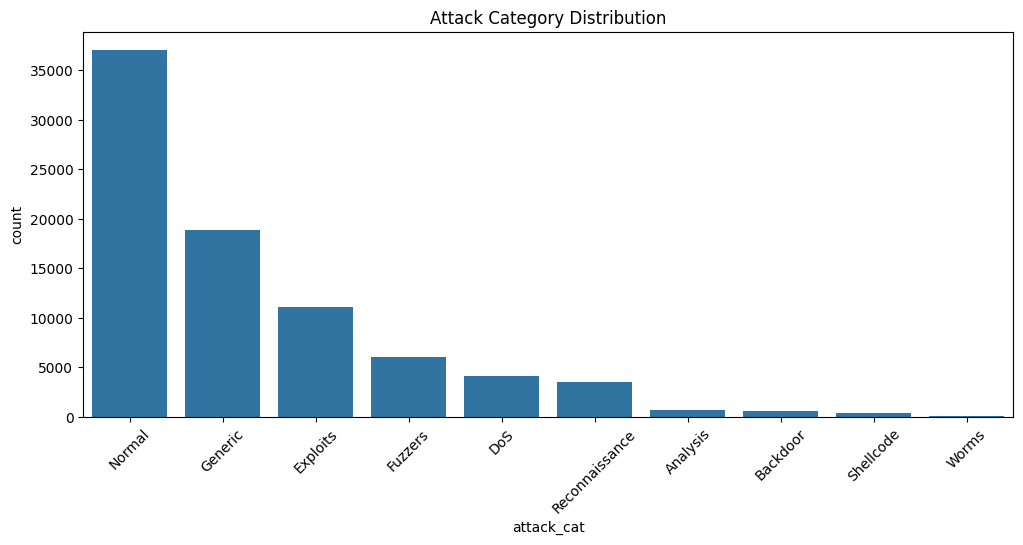

In [ ]:
#Different types of attacks shown for most to least
plt.figure(figsize=(12,5))
sns.countplot(x='attack_cat', data=train_df, order=train_df['attack_cat'].value_counts().index)
plt.title('Attack Category Distribution')
plt.xticks(rotation=45)
plt.show()

The chart above shows the attack traffic in more detail. Going in order from most common Normal attacks to more complex least common attacks which would be worms. This is good for our model to have a good idea on what to prepare the AI for.

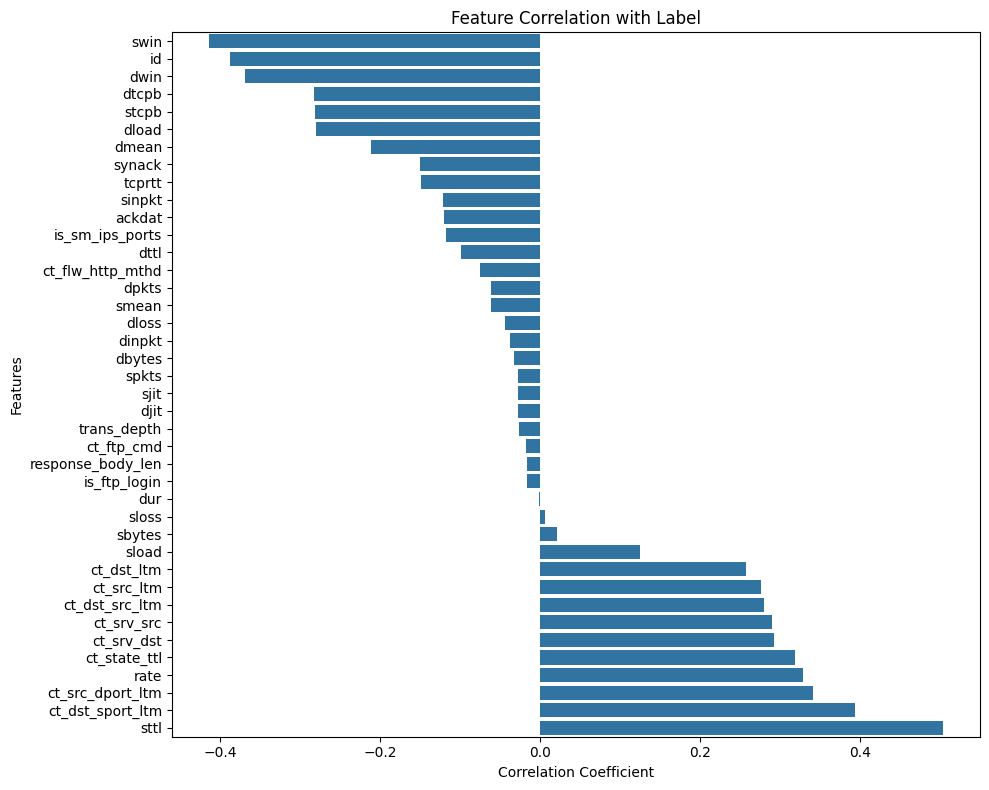

In [ ]:
plt.figure(figsize=(10,8))
numeric_df = train_df.select_dtypes(include=['number']).copy()
# Ensure 'label' is treated as a number for correlation, if it isn't already
numeric_df['label'] = numeric_df['label'].astype(int)
label_corr = numeric_df.corr()['label'].drop('label').sort_values()
sns.barplot(x=label_corr.values, y=label_corr.index)
plt.title('Feature Correlation with Label')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.ylabel('Features')
plt.show()

This chart shows the corrilation between each feature. A bar with a possitive corrilation (bar to the right) shows that that feature with that corrilation is likely to be an attack. While a bar with a negative corrilation (bar to the left) decrease the likely hood of it being an attack and its most likely safe.

**Breakdown of key features of data:**

Below is just a breakdown of some of the data. Just so there is a key understanding all around:

sttl (Source time to live) - A timer assigned to each network packet. Attack packets tend to have a different sttl than normal packets.

swin (Source TCP Window Size)- The size of the "window" a computer uses
  to send data. Normal connections typically have larger window sizes than attacks.

dwin (Destaination window size) - Similar concept as swin but measured
  from the receiving end.

rate -  A count of connections with the same state. Attack traffic tends to create patterns in this count.

In [ ]:
#shows coloums
cat_cols = ['proto', 'service', 'state']

for col in cat_cols:
    print(f"\n{col} — {train_df[col].nunique()} unique values")
    print(train_df[col].value_counts().head(5))


proto — 131 unique values
proto
tcp     43095
udp     29418
unas     3515
arp       987
ospf      676
Name: count, dtype: int64

service — 13 unique values
service
-       47153
dns     21367
http     8287
smtp     1851
ftp      1552
Name: count, dtype: int64

state — 7 unique values
state
FIN    39339
INT    34163
CON     6982
REQ     1842
ACC        4
Name: count, dtype: int64


This shows us that this data set has 3 categorical columns that being proto,service, and state. The proto column has 131 unique values, service has 13, and state has 7 uqiue values.  

In [ ]:
train_df = train_df.drop(columns=['id', 'attack_cat'], errors='ignore')
test_df = test_df.drop(columns=['id', 'attack_cat'], errors='ignore')

# Label for proto encoding
from sklearn.preprocessing import LabelEncoder

# Ensure 'proto' columns are strings before encoding
train_df['proto'] = train_df['proto'].astype(str)
test_df['proto'] = test_df['proto'].astype(str)

# Fit on combined proto values to prevent unseen label errors during transform
all_protos = pd.concat([train_df['proto'], test_df['proto']], axis=0).unique()
le = LabelEncoder()
le.fit(all_protos) # Fit on all unique proto values

train_df['proto'] = le.transform(train_df['proto'])
test_df['proto'] = le.transform(test_df['proto'])

#encoding
columns_to_encode = []
if 'service' in train_df.columns:
    columns_to_encode.append('service')
if 'state' in train_df.columns:
    columns_to_encode.append('state')

if columns_to_encode:
    train_df = pd.get_dummies(train_df, columns=columns_to_encode)
    test_df = pd.get_dummies(test_df, columns=columns_to_encode)

print("Training set shape after encoding:", train_df.shape)
print("Testing set shape after encoding:", test_df.shape)

#spliting the features and variables
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

Training set shape after encoding: (82332, 61)
Testing set shape after encoding: (175341, 63)


In [ ]:
# Align test set to training set columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Columns match:", X_train.shape[1] == X_test.shape[1])

X_train shape: (82332, 60)
X_test shape: (175341, 60)
Columns match: True


So what the cell does above is make sure the data is alligned and make sure that they are both on the same page. This makes the data good for modeling.

In [ ]:
# Check for missing values
print("Training set missing values:")
print(train_df.isnull().sum().sum())
print("Testing set missing values:")
print(test_df.isnull().sum().sum())

Training set missing values:
0
Testing set missing values:
0


The cell above shows that there is no missing values in the training and testing set.

**DELIVERABLE 3: Modeling, Evaluation & Insights**


Before we model the data set we have to split it up. The features (x) and the variables (y). This will make sure that data is learned from by the model.

In [ ]:
#below is code that caused errors I think I commented it for now
#spliting the features and variables
# These variables are now defined in an earlier cell to prevent NameError.
# X_train = train_df.drop(columns=['label'])
# y_train = train_df['label']

# X_test = test_df.drop(columns=['label'])
# y_test = test_df['label']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (82332, 60)
X_test shape: (175341, 60)
y_train shape: (82332,)
y_test shape: (175341,)


The output can look confusing at first but here is a breakdown.

**X_train shape: (82332, 60)** - 82332 is the number of rows and each row is a network connection. 60 is the feature in the column that the module will use to make its judment.  


**X_test shape: (175341, 60)** - 175341 network connections the modle have never seen before. Think of this as a test.


**y_train shape: (82332,)** - 82332 is the values (0,1) of each 82332 network connections.


**y_test shape: (175341,)** - This is the answers for the network connectons so that we can see how the model does.



Think of this as one big test and these are all parts of it. This is good for helping our train.


In [ ]:
# Align test set columns to match training set
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Columns match:", X_train.shape[1] == X_test.shape[1])

X_train shape: (82332, 60)
X_test shape: (175341, 60)
Columns match: True


## Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, cohen_kappa_score

# baseline AI
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Output
print("Regression results")
print(classification_report(y_test, lr_pred))
print("Score:", cohen_kappa_score(y_test, lr_pred))

Regression results
              precision    recall  f1-score   support

           0       0.55      0.92      0.69     56000
           1       0.95      0.65      0.77    119341

    accuracy                           0.74    175341
   macro avg       0.75      0.79      0.73    175341
weighted avg       0.82      0.74      0.75    175341

Score: 0.4884019494706965


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Above is a logistic regression model which helps us get a baseline for our random forest model. This model will be used as a comparison point.

A big problem with the regression model is that it only detects about 35% of attacks. So out goal with the random forest (the code below) is to surpass this 35% detection rate.

## Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

#Output
print("Ai results (random forest)")
print(classification_report(y_test, rf_pred))
print("Score:", cohen_kappa_score(y_test, rf_pred))

Ai results (random forest)
              precision    recall  f1-score   support

           0       0.77      0.98      0.86     56000
           1       0.99      0.87      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341

Score: 0.7878769914309919


The random forest model cell shows a significant improvement over the regression model. The chart under this cell shows the improvement between the two models. Mainly is the metrics of Kappa, Attack recall, Attack F1, and Accuracy.



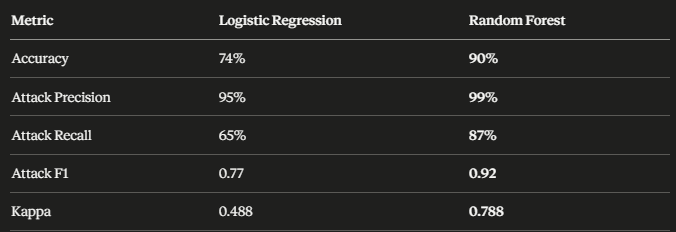

This chart shows the comparison between models and the improvement

## Tuning that data:

*Note: This cell will take over 12 minutes to run due to the size of that data!*

In [ ]:
from sklearn.model_selection import GridSearchCV

# grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV (will help us look for classifiers)
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Output:", grid_search.best_score_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Output: 0.931272903604702


This is the output if you dont want to wait for the cell to run:


*Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Output: 0.931272903604702*

The output of the cell above shows the most optimal parameters for us to use on  the random forest model to tune it.

## Improved Random forest model

In [ ]:
#For transparency I had Claude help me on how I can improve the forest model (this code)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, cohen_kappa_score

# Build tuned Random Forest with best parameters
rf_tuned = RandomForestClassifier(
    max_depth=None,
    min_samples_split=2,
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)
tuned_pred = rf_tuned.predict(X_test)

print("Improved AI")
print(classification_report(y_test, tuned_pred))
print("Score:", cohen_kappa_score(y_test, tuned_pred))

Improved AI
              precision    recall  f1-score   support

           0       0.77      0.98      0.86     56000
           1       0.99      0.86      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341

Score: 0.7868307509015907


## Findings of the improved AI:

The changes are very interesting. There is no major changes between the models which shows us the orginal random forest was optomised for this model.

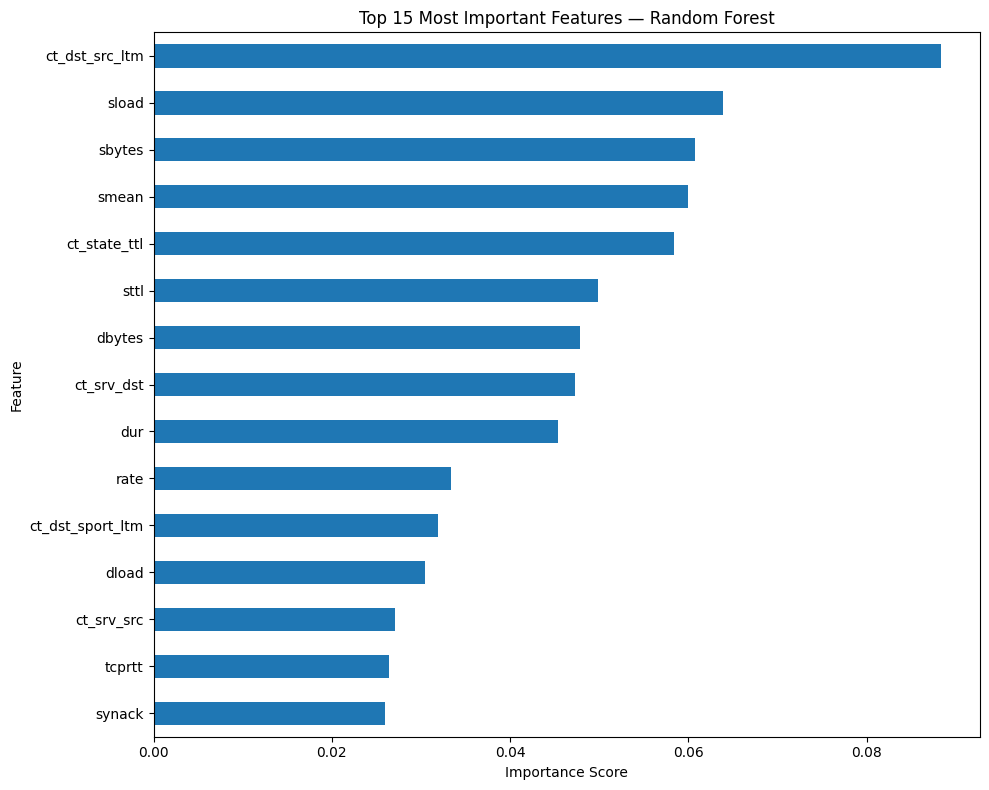

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
feature_importance = pd.Series(
    rf_tuned.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(15)

# chart
plt.figure(figsize=(10, 8))
feature_importance.plot(kind='barh')
plt.title('Top 15 Most Important Features: Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The chart above lets us know the 15 most important feature model preduction. These are the most important features to determan if a file is an attack on or not.


- ct_dst_src_ltm is by far the most important feature (0.088), this represents the count of connections between the same source and destination.

- sload (0.065) and sbytes (0.062) measures source load and bytes sent,
  meaning attack traffic generates distinctly different data than normal traffic.

- smean (0.060) represents the mean packet size from the source, attack
  packets tend to have unusual (larger or smaller: Typically larger) packet size.

- ct_state_ttl (0.058) and sttl (0.050) both appeared as strong
  correlators.

- dur (duration) and rate indicate that attacks have distinctly different connection timing patterns.

<Figure size 800x600 with 0 Axes>

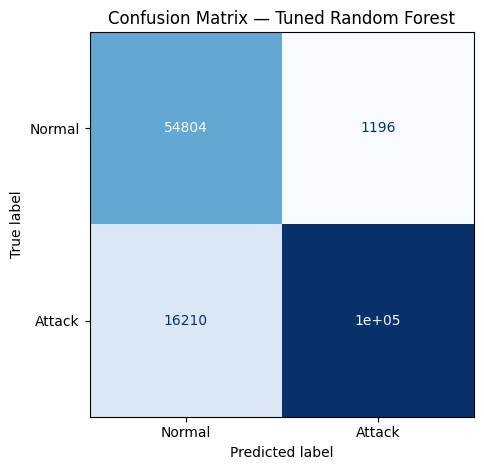

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, tuned_pred)

# chart plot
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'Attack'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Tuned Random Forest')
plt.tight_layout()
plt.show()

The cell above is the confusion matrix which shows:

- 54,804 normal connections were correctly classified as normal

- 103,131 attack connections were correctly identified as malicious

- 1,196 normal connections were incorrectly flagged as attacks (false positives)

- 16,210 attacks were missed entirely (false negatives) which is very bad. But, this represents only
13.6% of all attack traffic, meaning the model successfully detected
86.4% of all bad connections.

## Conclusion from all this data:

# Key information:

The Random forest had 90% accuracy in detection of malicious network traffic. This out preforms the logistic regression that was 74%. Tuning the model showed that the model was already really good at its baseline.

# Top Indicators of attacks:

Based on the feature importance the strongest indecators of malicious attacks are: ct_dst_src_ltm (repeated connections to the same destination), sload and sbytes (unusual data volumes), and sttl and ct_state_ttl (non normal time to time traffic)

# How do we apply this to the real world?:

This model can be used to help company in their cybersecurity. This can be done by automating their threat detection, help manage workload to the most important cybersecurity matters, and reduce defense response time (removing threats faster)

# Limitations:

The 16,210 missed attacks (false negatives) represent the models biggest problem. Also, the dataset may not fully represent real world attack senerios some times.


# Conclusion:

In conclusion, this assignment shows us that machine learning is highly effective for network cybersecurity. The model shows that it can detect 86% of attacks while maintaining a 90% accuracy rate. This provides a very strong foundation for cybersecurity teams.